<a href="https://colab.research.google.com/github/deepthi25p/Tiny_Object_Detection_in_Ariel_Images/blob/main/Tiny_Object_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install torch torchvision matplotlib opencv-python numpy pillow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.4 MB/s eta 0:00:00


In [3]:
!pip install kagglehub

In [4]:
import kagglehub

path = kagglehub.dataset_download("kushagrapandya/visdrone-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.10G/2.10G [02:12<00:00, 17.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1


In [5]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    break

/root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1


In [6]:
os.listdir(path)

['VisDrone2019-DET-val',
 'VisDrone2019-DET-test-dev',
 'VisDrone.yaml',
 'VisDrone2019-DET-train',
 'VisDrone2019-DET-test-challenge']

In [7]:
import os

base = path + "/VisDrone2019-DET-train"
print(os.listdir(base))

['VisDrone2019-DET-train']


In [8]:
import os

new_path = os.path.join(path, "VisDrone2019-DET-train")
print(os.listdir(new_path))

['VisDrone2019-DET-train']


In [9]:
import os

level1 = os.path.join(path, "VisDrone2019-DET-train")
level2 = os.path.join(level1, "VisDrone2019-DET-train")

print(os.listdir(level2))

['images', 'annotations']


In [10]:
import cv2

def convert_visdrone(img_dir, ann_dir, label_dir):
    os.makedirs(label_dir, exist_ok=True)

    for ann_file in os.listdir(ann_dir):
        if not ann_file.endswith('.txt'):
            continue

        img_file = ann_file.replace('.txt', '.jpg')
        img_path = os.path.join(img_dir, img_file)
        ann_path = os.path.join(ann_dir, ann_file)

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w, _ = img.shape
        yolo_lines = []

        with open(ann_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            data = line.strip().split(',')
            x, y, bw, bh, score, cls, trunc, occ = map(int, data)

            if score == 0:
                continue

            x_center = (x + bw / 2) / w
            y_center = (y + bh / 2) / h
            bw /= w
            bh /= h

            cls_id = cls - 1

            yolo_lines.append(f"{cls_id} {x_center} {y_center} {bw} {bh}")

        with open(os.path.join(label_dir, ann_file), 'w') as f:
            f.write("\n".join(yolo_lines))

In [11]:
import os

# define paths again
train_path = os.path.join(path, "VisDrone2019-DET-train", "VisDrone2019-DET-train")
val_path = os.path.join(path, "VisDrone2019-DET-val", "VisDrone2019-DET-val")

print("Train path:", train_path)
print("Val path:", val_path)

Train path: /root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1/VisDrone2019-DET-train/VisDrone2019-DET-train
Val path: /root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1/VisDrone2019-DET-val/VisDrone2019-DET-val


In [12]:
import os
import cv2

def convert_visdrone(img_dir, ann_dir, label_dir):
    os.makedirs(label_dir, exist_ok=True)

    for ann_file in os.listdir(ann_dir):
        if not ann_file.endswith('.txt'):
            continue

        img_file = ann_file.replace('.txt', '.jpg')
        img_path = os.path.join(img_dir, img_file)
        ann_path = os.path.join(ann_dir, ann_file)

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w, _ = img.shape
        yolo_lines = []

        with open(ann_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            data = line.strip().split(',')

            # ✅ FIX: skip bad/empty lines
            if len(data) < 8 or '' in data:
                continue

            try:
                x = float(data[0])
                y = float(data[1])
                bw = float(data[2])
                bh = float(data[3])
                score = int(data[4])
                cls = int(data[5])
            except:
                continue

            if score == 0:
                continue

            # convert to YOLO format
            x_center = (x + bw / 2) / w
            y_center = (y + bh / 2) / h
            bw /= w
            bh /= h

            cls_id = cls - 1

            yolo_lines.append(f"{cls_id} {x_center} {y_center} {bw} {bh}")

        # save label
        with open(os.path.join(label_dir, ann_file), 'w') as f:
            f.write("\n".join(yolo_lines))

In [13]:
convert_visdrone(
    img_dir=train_path + "/images",
    ann_dir=train_path + "/annotations",
    label_dir="/content/visdrone/labels/train"
)

convert_visdrone(
    img_dir=val_path + "/images",
    ann_dir=val_path + "/annotations",
    label_dir="/content/visdrone/labels/val"
)

In [14]:
import shutil
import os

os.makedirs("/content/visdrone/images/train", exist_ok=True)
os.makedirs("/content/visdrone/images/val", exist_ok=True)

shutil.copytree(train_path + "/images",
                "/content/visdrone/images/train",
                dirs_exist_ok=True)

shutil.copytree(val_path + "/images",
                "/content/visdrone/images/val",
                dirs_exist_ok=True)

'/content/visdrone/images/val'

In [15]:
data_yaml = """
path: /content/visdrone
train: images/train
val: images/val

names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor
"""

with open("/content/visdrone/data.yaml", "w") as f:
    f.write(data_yaml)

In [16]:
!pip install ultralytics

In [17]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/visdrone/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/visdrone/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cce1ef89e80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [20]:
import os

val_images = os.listdir("/content/visdrone/images/val")
print(val_images[:10])  # show first 10 images

['0000291_00001_d_0000868.jpg', '0000153_00801_d_0000001.jpg', '0000330_03001_d_0000815.jpg', '0000026_03000_d_0000030.jpg', '0000289_02001_d_0000821.jpg', '0000301_01201_d_0000162.jpg', '0000289_05001_d_0000836.jpg', '0000295_01200_d_0000027.jpg', '0000194_00625_d_0000122.jpg', '0000276_00601_d_0000510.jpg']


In [21]:
test_img = "/content/visdrone/images/val/" + val_images[0]
print(test_img)

/content/visdrone/images/val/0000291_00001_d_0000868.jpg


In [22]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

model(test_img, show=True)


image 1/1 /content/visdrone/images/val/0000291_00001_d_0000868.jpg: 384x640 5 pedestrians, 2 peoples, 35 cars, 4 vans, 1 bus, 2 motors, 68.2ms
Speed: 3.0ms preprocess, 68.2ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 4: 'van', 5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'}
 obb: None
 orig_img: array([[[170, 117,  67],
         [171, 118,  68],
         [172, 119,  69],
         ...,
         [178, 125,  82],
         [178, 125,  82],
         [178, 125,  82]],
 
        [[169, 116,  66],
         [170, 117,  67],
         [171, 118,  68],
         ...,
         [178, 125,  82],
         [178, 125,  82],
         [178, 125,  82]],
 
        [[168, 115,  65],
         [169, 116,  66],
         [170, 117,  67],
         ...,
         [177, 124,  81],
         [178, 125,  82],
         [178, 125,  82]],
 
        ...,
 
        [[ 91,  98, 101],
         [ 92,  99, 102],
         [ 92,  99, 102],
         ...,
         [ 29,  37,  44],
         [ 58,  64,  71],
         [ 60,  6

In [23]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

results = model("/content/visdrone/images/val/0000330_03001_d_0000815.jpg", save=True)


image 1/1 /content/visdrone/images/val/0000330_03001_d_0000815.jpg: 384x640 7 pedestrians, 5 peoples, 20 cars, 1 van, 1 tricycle, 1 motor, 16.8ms
Speed: 7.4ms preprocess, 16.8ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


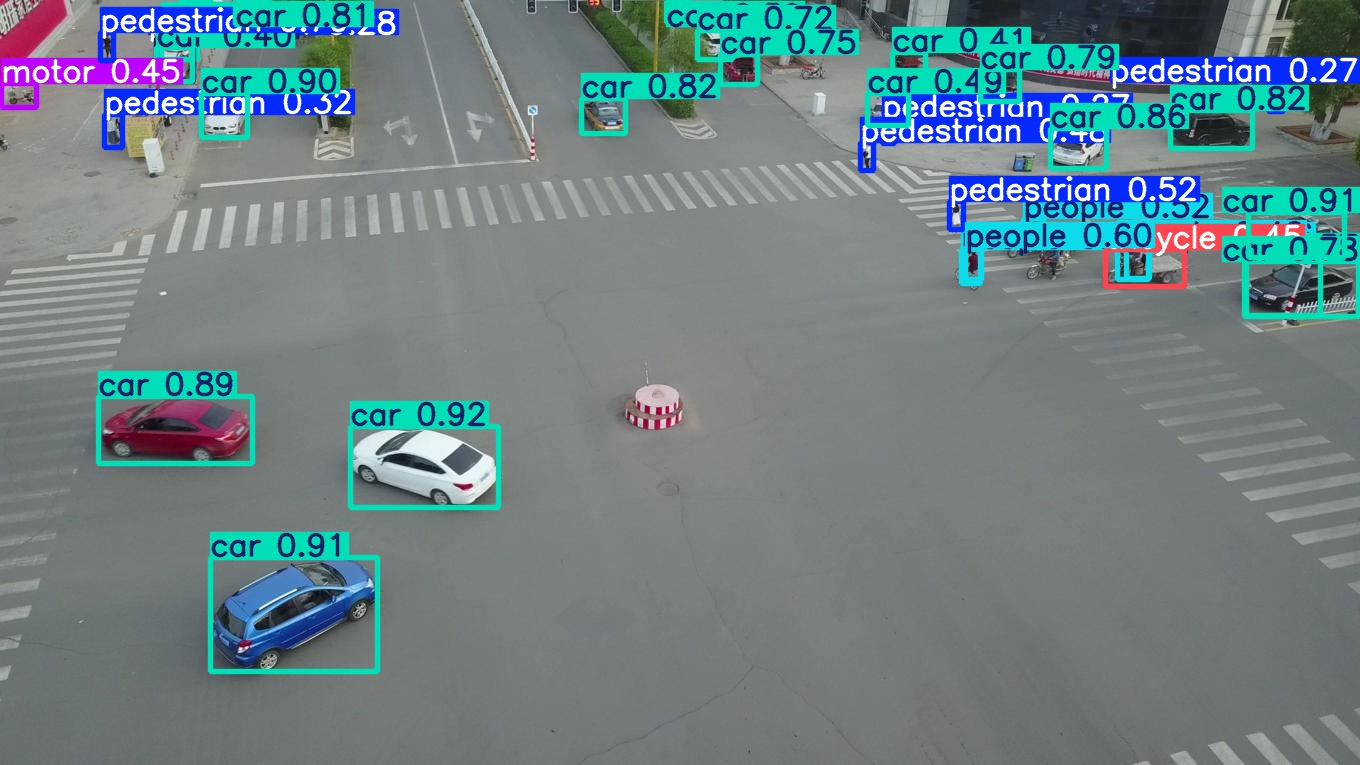

In [24]:
from IPython.display import Image, display
import os

# find latest prediction folder
pred_path = "runs/detect/predict"

# get latest saved image
files = os.listdir(pred_path)
files.sort()

output_img = os.path.join(pred_path, files[-1])

display(Image(filename=output_img))

In [25]:
#Tiling

In [26]:
import cv2
import os

def tile_image(image_path, tile_size=640):
    img = cv2.imread(image_path)
    h, w, _ = img.shape

    tiles = []
    coords = []

    for y in range(0, h, tile_size):
        for x in range(0, w, tile_size):
            tile = img[y:y+tile_size, x:x+tile_size]

            if tile.shape[0] == tile_size and tile.shape[1] == tile_size:
                tiles.append(tile)
                coords.append((x, y))

    return tiles, coords

In [27]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

image_path = "/content/visdrone/images/val/0000330_03001_d_0000815.jpg"

tiles, coords = tile_image(image_path)

results_list = []

for tile in tiles:
    results = model(tile)
    results_list.append(results)


0: 640x640 6 pedestrians, 10 cars, 2 vans, 2 motors, 9.1ms
Speed: 2.0ms preprocess, 9.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 pedestrians, 5 peoples, 2 bicycles, 8 cars, 1 van, 1 truck, 2 tricycles, 1 awning-tricycle, 6 motors, 7.7ms
Speed: 2.3ms preprocess, 7.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


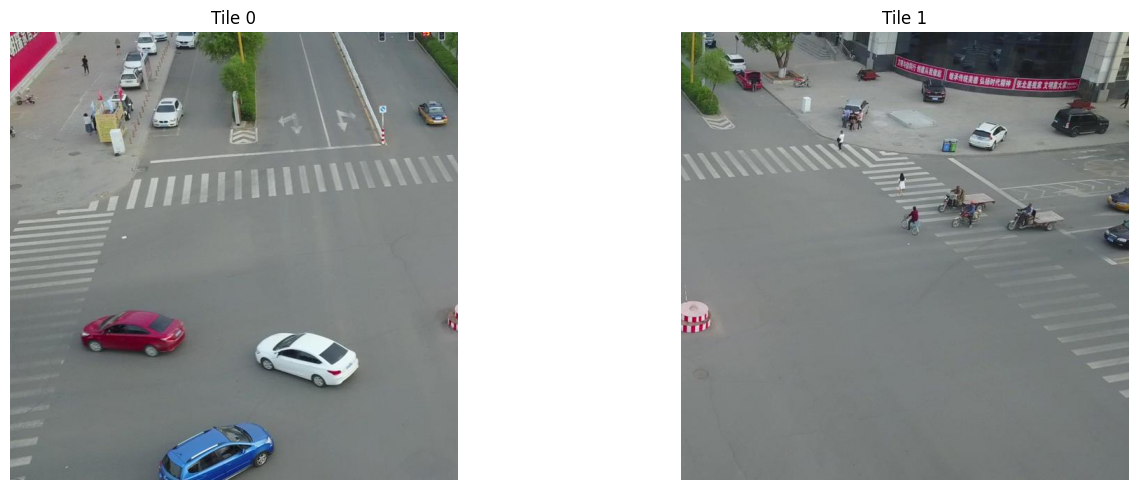

In [30]:
import cv2
import matplotlib.pyplot as plt

n = min(4, len(tiles))  # ✅ safe

fig, axes = plt.subplots(1, n, figsize=(15, 5))

# if only 1 tile, axes is not a list → fix
if n == 1:
    axes = [axes]

for i in range(n):
    axes[i].imshow(cv2.cvtColor(tiles[i], cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Tile {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [35]:
!pip install gradio

In [40]:
import gradio as gr
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

def detect(image):
    results = model(image)
    return results[0].plot()

# 🌙 Dark Theme
dark_theme = gr.themes.Base(
    primary_hue="blue",
    secondary_hue="purple",
    neutral_hue="gray"
)

# 🎨 Custom CSS for DARK LOOK
css = """
body {
    background-color: #0f172a;
    color: white;
}
.gradio-container {
    background-color: #0f172a;
}
h1, h2, h3 {
    color: #38bdf8;
}
"""

demo = gr.Interface(
    fn=detect,
    inputs=gr.Image(type="numpy"),
    outputs="image",
    theme=dark_theme,
    css=css,
    title="🚁 Tiny Object Detection (Aerial Images)",
    description="Detect small objects using YOLOv8 with a dark-themed UI"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fcc951204f24567d0f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [41]:
sample_path = "/content/visdrone/images/val/0000291_00001_d_0000868.jpg"

In [42]:
from google.colab import files
files.download(sample_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>